****
**LSTM**
****
At this stage, the previously prepared sequential traffic dataset is used directly for LSTM training. Since the data preprocessing, feature selection, scaling, and sequence generation have already been completed, the next step focuses on model training and evaluation rather than repeating the earlier preprocessing steps.

**Load and prepare the approach-based dataset**
This step loads the aggregated 15-minute approach-based traffic counts and prepares the dataset for forecasting.

In [3]:
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(r"C:\Users\mogul\OneDrive\Masaüstü\mt_emre\LSTM_Model")
APPROACH_CSV = BASE_DIR / "approach_counts_15min.csv"

# ============================================================
# LOAD
# ============================================================

approach_df = pd.read_csv(APPROACH_CSV)
approach_df["timestamp_berlin"] = pd.to_datetime(approach_df["timestamp_berlin"], errors="coerce")
approach_df = approach_df.sort_values("timestamp_berlin").reset_index(drop=True)

# ============================================================
# SELECT FEATURES
# ============================================================

feature_cols = [col for col in approach_df.columns if col.endswith("_count")]
data = approach_df[["timestamp_berlin"] + feature_cols].copy()

print("Selected features:")
print(feature_cols)
print("\nShape before missing-value handling:", data.shape)

# ============================================================
# HANDLE MISSING VALUES
# ============================================================

data[feature_cols] = data[feature_cols].ffill().bfill()

print("\nRemaining NaN values per feature:")
print(data[feature_cols].isna().sum())

Selected features:
['LD-LSA16_west_count', 'LD-LSA16_south_count', 'LD-LSA16_east_count', 'LD-LSA16_north_count', 'LD-LSA10_west_count', 'LD-LSA10_south_count', 'LD-LSA10_east_count', 'LD-LSA10_north_west_count', 'LD-LSA10_north_east_count', 'LD-LSA9_west_count', 'LD-LSA9_south_count', 'LD-LSA9_east_count', 'LD-LSA9_north_west_count', 'LD-LSA1_west_count', 'LD-LSA1_east_count', 'LD-LSA1_north_count']

Shape before missing-value handling: (2663, 17)

Remaining NaN values per feature:
LD-LSA16_west_count          0
LD-LSA16_south_count         0
LD-LSA16_east_count          0
LD-LSA16_north_count         0
LD-LSA10_west_count          0
LD-LSA10_south_count         0
LD-LSA10_east_count          0
LD-LSA10_north_west_count    0
LD-LSA10_north_east_count    0
LD-LSA9_west_count           0
LD-LSA9_south_count          0
LD-LSA9_east_count           0
LD-LSA9_north_west_count     0
LD-LSA1_west_count           0
LD-LSA1_east_count           0
LD-LSA1_north_count          0
dtype: int64


**2. Train-validation-test split**
The dataset is divided chronologically in order to preserve the temporal structure of the traffic time series.

In [4]:
# ============================================================
# SPLIT BY TIME
# ============================================================

n = len(data)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = data.iloc[:train_end].copy()
val_df   = data.iloc[train_end:val_end].copy()
test_df  = data.iloc[val_end:].copy()

print("Split sizes:")
print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

print("\nTime ranges:")
print("Train:", train_df["timestamp_berlin"].min(), "to", train_df["timestamp_berlin"].max())
print("Val:  ", val_df["timestamp_berlin"].min(), "to", val_df["timestamp_berlin"].max())
print("Test: ", test_df["timestamp_berlin"].min(), "to", test_df["timestamp_berlin"].max())

Split sizes:
Train: (1864, 17)
Validation: (399, 17)
Test: (400, 17)

Time ranges:
Train: 2026-03-01 01:15:00+01:00 to 2026-03-20 15:45:00+01:00
Val:   2026-03-20 16:00:00+01:00 to 2026-03-24 20:30:00+01:00
Test:  2026-03-24 20:45:00+01:00 to 2026-03-29 01:45:00+01:00


**3. Sequence generation**
The multivariate time series is transformed into sequential samples for one-step-ahead forecasting.


In [5]:
# ============================================================
# SETTINGS
# ============================================================

LOOKBACK = 4   # 4 x 15 min = 1 hour history
HORIZON = 1    # 1 step ahead = next 15-minute interval

# ============================================================
# SCALING
# ============================================================

scaler = MinMaxScaler()
scaler.fit(train_df[feature_cols])

train_scaled = scaler.transform(train_df[feature_cols])
val_scaled   = scaler.transform(val_df[feature_cols])
test_scaled  = scaler.transform(test_df[feature_cols])

# ============================================================
# SEQUENCE FUNCTION
# ============================================================

def create_sequences(array_2d, lookback=4, horizon=1):
    X, y = [], []
    for i in range(len(array_2d) - lookback - horizon + 1):
        X.append(array_2d[i:i+lookback])
        y.append(array_2d[i+lookback+horizon-1])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_scaled, LOOKBACK, HORIZON)
X_val, y_val     = create_sequences(val_scaled, LOOKBACK, HORIZON)
X_test, y_test   = create_sequences(test_scaled, LOOKBACK, HORIZON)

print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val:  ", X_val.shape, "y_val:", y_val.shape)
print("X_test: ", X_test.shape, "y_test:", y_test.shape)

X_train: (1860, 4, 16) y_train: (1860, 16)
X_val:   (395, 4, 16) y_val: (395, 16)
X_test:  (396, 4, 16) y_test: (396, 16)


In [6]:
def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# naive prediction = last observed step
y_pred_naive_scaled = X_test[:, -1, :]

# inverse transform to original scale
y_test_actual = scaler.inverse_transform(y_test)
y_pred_naive_actual = scaler.inverse_transform(y_pred_naive_scaled)

overall_mae_naive = mean_absolute_error(y_test_actual, y_pred_naive_actual)
overall_rmse_naive = rmse(y_test_actual, y_pred_naive_actual)

print("Naive baseline performance:")
print("Overall MAE :", round(overall_mae_naive, 3))
print("Overall RMSE:", round(overall_rmse_naive, 3))

Naive baseline performance:
Overall MAE : 8.847
Overall RMSE: 17.014


****
**LSTM model**
***
An LSTM model is trained to learn temporal dependencies in the multivariate traffic count series.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

n_features = X_train.shape[2]

model = Sequential([
    LSTM(64, input_shape=(LOOKBACK, n_features)),
    Dropout(0.2),
    Dense(n_features)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

c:\Users\mogul\AppData\Local\Programs\Python\Python39\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        20,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,776 (85.06 KB)

 Trainable params: 21,776 (85.06 KB)

 Non-trainable params: 0 (0.00 B)

**LSTM training**
The model is trained on the training set and validated on unseen validation data. Early stopping is used to reduce overfitting.

In [8]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=30,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0711 - val_loss: 0.0113
Epoch 2/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0178 - val_loss: 0.0087
Epoch 3/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0124 - val_loss: 0.0071
Epoch 4/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0112 - val_loss: 0.0064
Epoch 5/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0102 - val_loss: 0.0060
Epoch 6/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0092 - val_loss: 0.0057
Epoch 7/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0088 - val_loss: 0.0056
Epoch 8/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0084 - val_loss: 0.0056
Epoch 9/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0086 - val_loss: 0.0054
Epoch 10/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0078 - val_loss: 0.0054
Epoch 11/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0078 - val_loss: 0.0053
Epoch 12/30
59/59 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0074 - val_l

**LSTM prediction and model comparison**
The trained LSTM model is applied to the test set and compared with the naive baseline.

In [9]:
# ============================================================
# LSTM PREDICTION
# ============================================================

y_pred_lstm_scaled = model.predict(X_test)
y_pred_lstm_actual = scaler.inverse_transform(y_pred_lstm_scaled)

overall_mae_lstm = mean_absolute_error(y_test_actual, y_pred_lstm_actual)
overall_rmse_lstm = rmse(y_test_actual, y_pred_lstm_actual)

print("Naive baseline:")
print("MAE :", round(overall_mae_naive, 3))
print("RMSE:", round(overall_rmse_naive, 3))

print("\nLSTM:")
print("MAE :", round(overall_mae_lstm, 3))
print("RMSE:", round(overall_rmse_lstm, 3))

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Naive baseline:
MAE : 8.847
RMSE: 17.014

LSTM:
MAE : 9.225
RMSE: 17.073


**Visualization of actual, naive, and LSTM predictions**
This step compares the observed traffic counts with the naive baseline and LSTM forecasts for selected approaches.

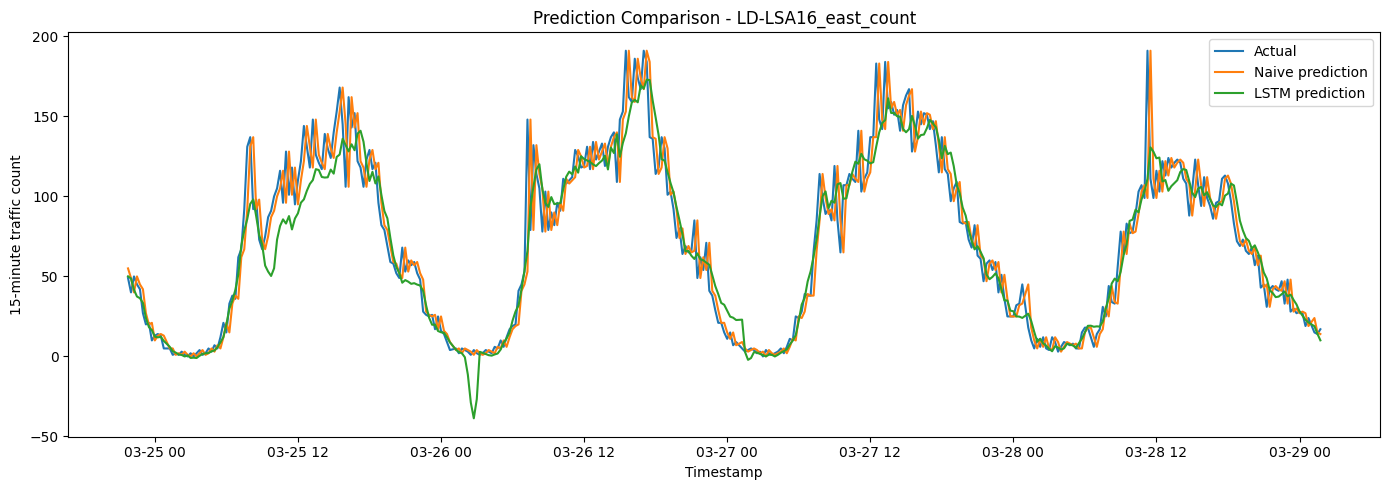

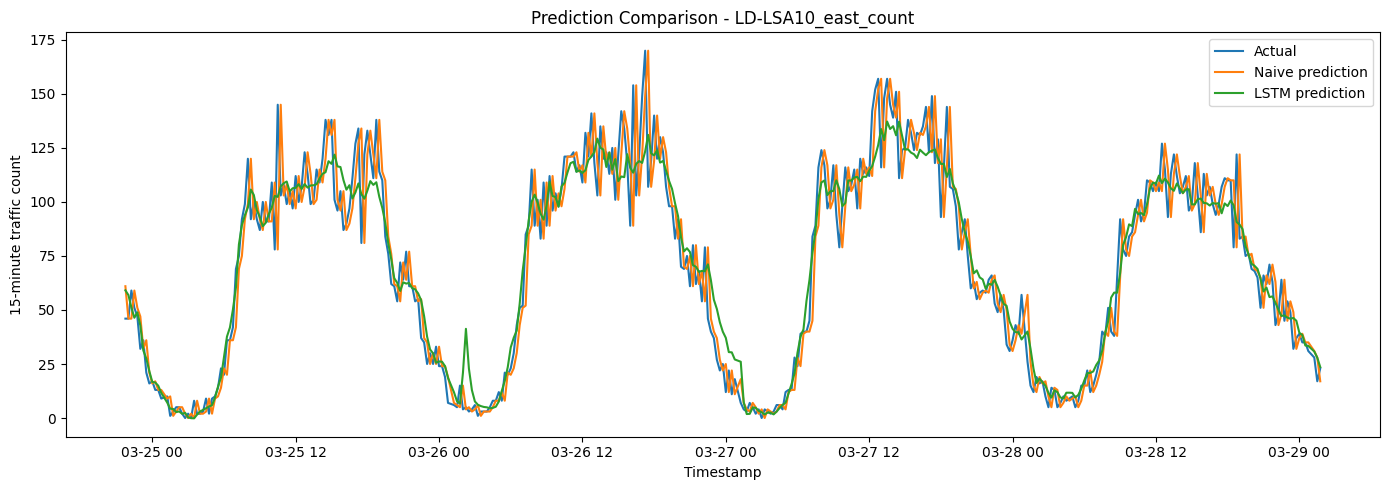

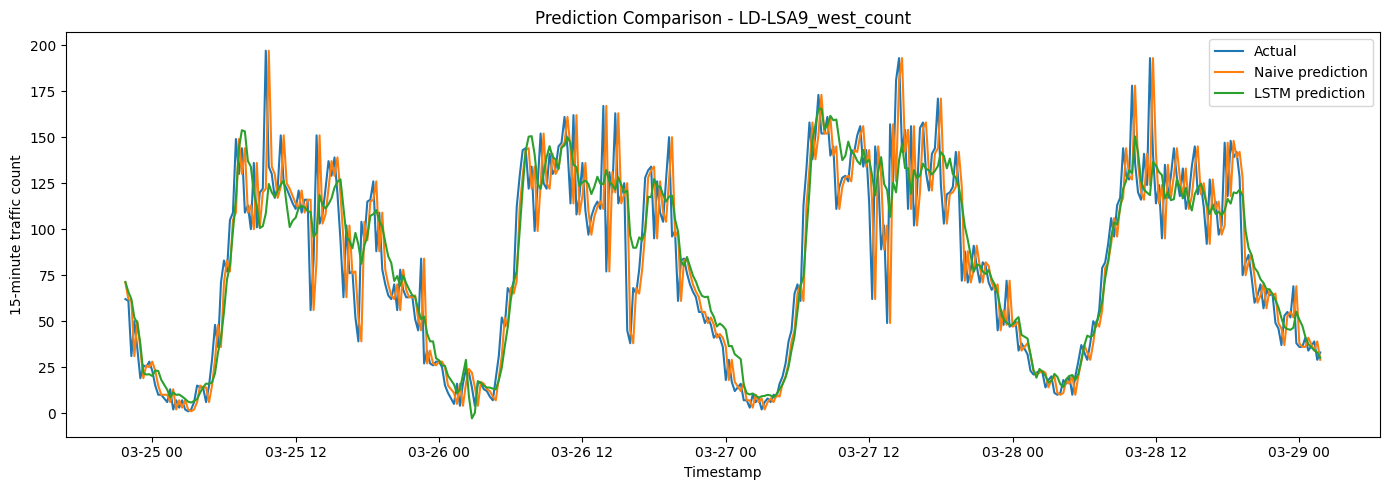

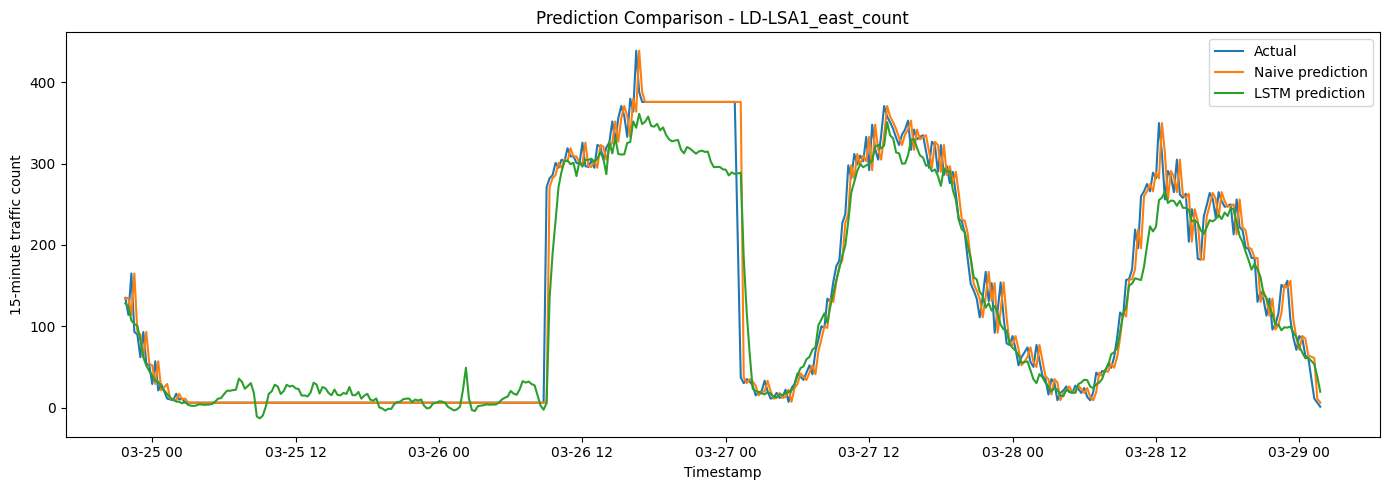

In [10]:
import matplotlib.pyplot as plt

plot_features = [
    "LD-LSA16_east_count",
    "LD-LSA10_east_count",
    "LD-LSA9_west_count",
    "LD-LSA1_east_count",
]

test_timestamps = test_df["timestamp_berlin"].iloc[LOOKBACK + HORIZON - 1:].reset_index(drop=True)

for feature in plot_features:
    if feature not in feature_cols:
        continue

    idx = feature_cols.index(feature)

    plt.figure(figsize=(14, 5))
    plt.plot(test_timestamps, y_test_actual[:, idx], label="Actual")
    plt.plot(test_timestamps, y_pred_naive_actual[:, idx], label="Naive prediction")
    plt.plot(test_timestamps, y_pred_lstm_actual[:, idx], label="LSTM prediction")

    plt.title(f"Prediction Comparison - {feature}")
    plt.xlabel("Timestamp")
    plt.ylabel("15-minute traffic count")
    plt.legend()
    plt.tight_layout()
    plt.show()